# 04 - Model Training and Evaluation

## Objective

The objective of this notebook is to develop and evaluate multiple machine learning models for vehicular misbehavior detection using the processed VeReMi dataset.

This notebook includes:

- Loading processed datasets
- Model training
- Performance evaluation
- Model comparison
- Saving trained models
- Preparing the best model for explainability using SHAP

The evaluation follows a reproducible experimental pipeline suitable for research publication.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

In [3]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [4]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix,

    classification_report,

    roc_curve,

    precision_recall_curve

)

## Loading Processed Training and Testing Datasets

The processed datasets generated in Notebook 03 are loaded for model development.

Each dataset already contains:

- cleaned features
- engineered features
- standardized numerical features
- target labels
- train/test split

In [7]:
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data"

PROCESSED_PATH = DATA_PATH / "processed"

MODEL_PATH = PROJECT_ROOT / "models"

OUTPUT_PATH = PROJECT_ROOT / "outputs"

FIGURE_PATH = OUTPUT_PATH / "figures"

METRIC_PATH = OUTPUT_PATH / "metrics"

REPORT_PATH = OUTPUT_PATH / "reports"

In [14]:
BASELINE_MODEL_PATH = MODEL_PATH / "baseline_models"

SAVED_MODEL_PATH = MODEL_PATH / "saved_models"

PREPROCESSING_MODEL_PATH = MODEL_PATH / "preprocessing"

EXPLAINABILITY_PATH = MODEL_PATH / "explainability"

SHAP_PATH = MODEL_PATH / "shap_values"

In [8]:
train_df = pd.read_csv(PROCESSED_PATH / "train_processed.csv")

test_df = pd.read_csv(PROCESSED_PATH / "test_processed.csv")

In [9]:
print(train_df.shape)

print(test_df.shape)

(80000, 23)
(20000, 23)


In [10]:
train_df.columns

Index(['type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1',
       'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1',
       'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0',
       'hed_noise_1', 'pos_magnitude', 'speed_magnitude',
       'acceleration_magnitude', 'heading_magnitude', 'attack'],
      dtype='str')

## Preparing Features and Target

The processed datasets are separated into predictor variables (X) and the target variable (y).

The target variable is:

- **attack**

All remaining columns are used as predictive features.

In [11]:
X_train = train_df.drop(columns=["attack"])

y_train = train_df["attack"]

X_test = test_df.drop(columns=["attack"])

y_test = test_df["attack"]

In [12]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (80000, 22)
Testing Features : (20000, 22)
Training Labels : (80000,)
Testing Labels : (20000,)


In [13]:
import joblib

# Metadata files
feature_names = joblib.load(
    MODEL_PATH / "feature_names.pkl"
)

target_column = joblib.load(
    MODEL_PATH / "target_column.pkl"
)

dataset_metadata = joblib.load(
    MODEL_PATH / "dataset_metadata.pkl"
)

# Preprocessing artifact
scaler = joblib.load(
    MODEL_PATH / "preprocessing" / "standard_scaler.pkl"
)

# 6. Machine Learning Libraries

This section imports the machine learning algorithms and evaluation metrics required for training and assessing baseline classification models.

The first baseline model implemented is Logistic Regression, which provides a simple linear classifier against which more complex ensemble methods can be compared.

In [15]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# 7. Model Evaluation Utilities

To maintain consistency across all machine learning models, reusable evaluation functions are created.

These functions calculate:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

The same utilities will be reused for every model in this project.

In [16]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

In [17]:
def print_metrics(metrics):

    results = pd.DataFrame(metrics.items(),
                           columns=["Metric","Value"])

    display(results)

In [18]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title(title)

    plt.tight_layout()

    plt.show()

In [19]:
def plot_roc_curve(y_test, y_prob, title):

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr)

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.tight_layout()

    plt.show()

In [20]:
def plot_pr_curve(y_test, y_prob, title):

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(6,5))

    plt.plot(recall, precision)

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title(title)

    plt.tight_layout()

    plt.show()

# 8. Baseline Model 1 — Logistic Regression

Logistic Regression is selected as the first baseline classifier.

Although it assumes a linear decision boundary, it provides a strong benchmark for evaluating the effectiveness of more sophisticated ensemble models developed later in the project.

In [21]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [22]:
import joblib

joblib.dump(
    log_reg,
    BASELINE_MODEL_PATH / "logistic_regression.pkl"
)

['..\\models\\baseline_models\\logistic_regression.pkl']

# 9. Model Prediction

After training the Logistic Regression classifier, predictions are generated on the unseen test dataset.

Two outputs are produced:

- Predicted class labels
- Predicted probabilities

The probabilities are required for ROC-AUC analysis and Precision–Recall evaluation.

In [23]:
y_pred = log_reg.predict(X_test)

y_prob = log_reg.predict_proba(X_test)[:, 1]

In [24]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})

prediction_df.head(10)

,Actual,Predicted,Probability
0,0,0,0.421370
1,0,0,0.468411
2,1,0,0.476821
3,0,0,0.497558
4,1,0,0.475399
5,0,0,0.423229
6,0,0,0.428278
7,0,0,0.477694
8,1,0,0.491543
9,1,0,0.465160


# 10. Model Performance Evaluation

The Logistic Regression classifier is evaluated using standard binary classification metrics.

The following performance indicators are computed:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC Score

These metrics establish a baseline for comparison with more advanced models developed later in this research.

In [25]:
metrics, y_pred, y_prob = evaluate_model(
    log_reg,
    X_test,
    y_test
)

In [26]:
print_metrics(metrics)

,Metric,Value
0,Accuracy,0.545200
1,Precision,0.497748
2,Recall,0.024302
3,F1 Score,0.046341
4,ROC AUC,0.534808


In [28]:
metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

metrics_df.to_csv(
    METRIC_PATH / "logistic_regression_metrics.csv",
    index=False
)

metrics_df

,Metric,Value
0,Accuracy,0.545200
1,Precision,0.497748
2,Recall,0.024302
3,F1 Score,0.046341
4,ROC AUC,0.534808


# 11. Confusion Matrix

The confusion matrix summarizes the prediction outcomes by comparing the actual and predicted class labels.

It provides insight into:

- True Positives
- True Negatives
- False Positives
- False Negatives

This analysis helps identify the types of errors made by the classifier.

In [29]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[10683,   223],
       [ 8873,   221]])

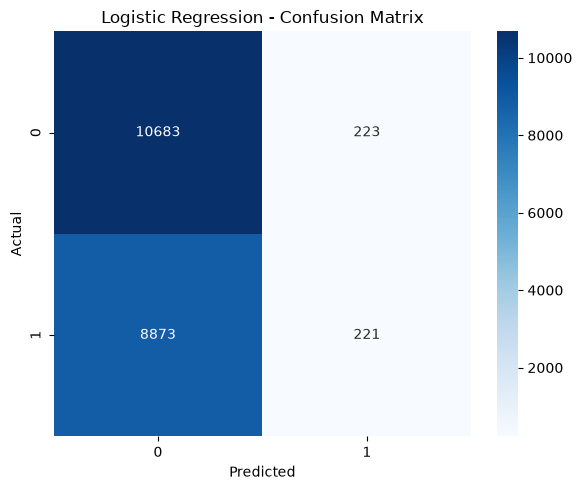

In [30]:
plot_confusion_matrix(
    cm,
    "Logistic Regression - Confusion Matrix"
)

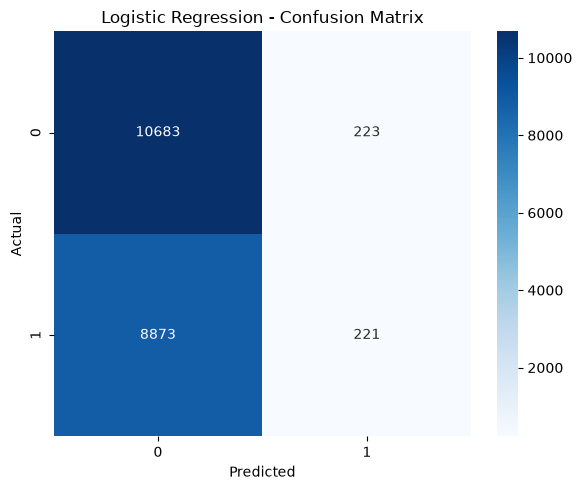

In [31]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH /
    "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 12. Classification Report

The classification report provides detailed class-wise performance statistics including precision, recall, F1-score, and support.

This report complements the confusion matrix by quantifying the classifier's predictive performance for each class.

In [33]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.546277,0.979553,0.701398,10906.0000
1,0.497748,0.024302,0.046341,9094.0000
accuracy,0.545200,0.545200,0.545200,0.5452
macro avg,0.522013,0.501927,0.373870,20000.0000
weighted avg,0.524211,0.545200,0.403544,20000.0000


In [34]:
report_df.to_csv(
    REPORT_PATH /
    "logistic_regression_classification_report.csv"
)

## Discussion of Logistic Regression Results

The Logistic Regression model achieved an accuracy of approximately **54.5%**, which is close to the proportion of the majority class in the dataset. This indicates that the classifier predominantly predicts the majority class.

Although the model obtained a precision of approximately **49.8%**, its recall was only **2.4%**, meaning that the vast majority of attack instances were incorrectly classified as normal messages.

The confusion matrix confirms this behaviour, with **8,873 attack samples misclassified** and only **221 attacks correctly detected**.

Similarly, the ROC-AUC score of **0.535** suggests that the model performs only marginally better than random guessing.

These observations demonstrate that a simple linear classifier is insufficient for modelling the complex relationships present in the VeReMi dataset. Consequently, more powerful non-linear machine learning models will be investigated in the following sections.

# 13. Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate at different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) provides a threshold-independent measure of model performance.

A ROC-AUC score close to 0.5 indicates random classification, whereas a score close to 1.0 indicates excellent discriminative capability.

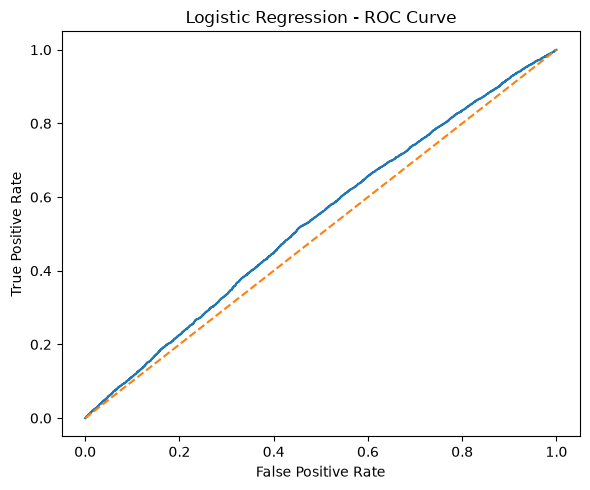

In [35]:
plot_roc_curve(
    y_test,
    y_prob,
    "Logistic Regression - ROC Curve"
)

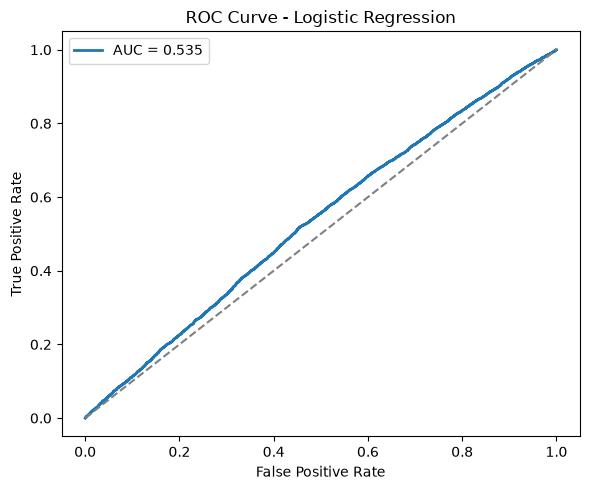

In [36]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {metrics['ROC AUC']:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_PATH /
    "logistic_regression_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 14. Precision-Recall Curve

The Precision-Recall Curve evaluates the balance between precision and recall across different probability thresholds.

This visualization is particularly useful for datasets where detecting the positive class is critical.

Since vehicular attack detection prioritizes identifying malicious messages, the Precision-Recall Curve provides valuable insight into the classifier's effectiveness.

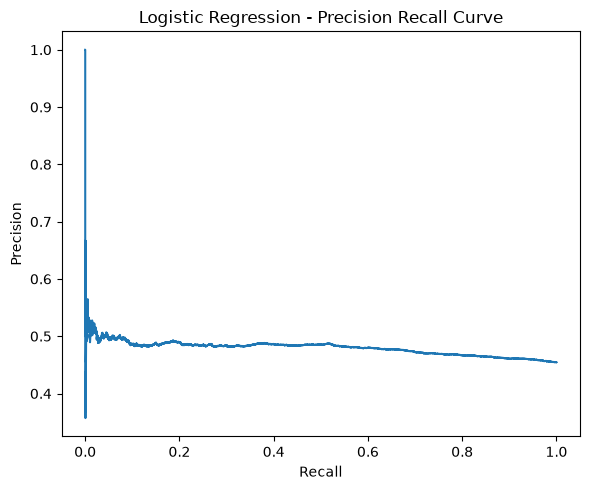

In [37]:
plot_pr_curve(
    y_test,
    y_prob,
    "Logistic Regression - Precision Recall Curve"
)

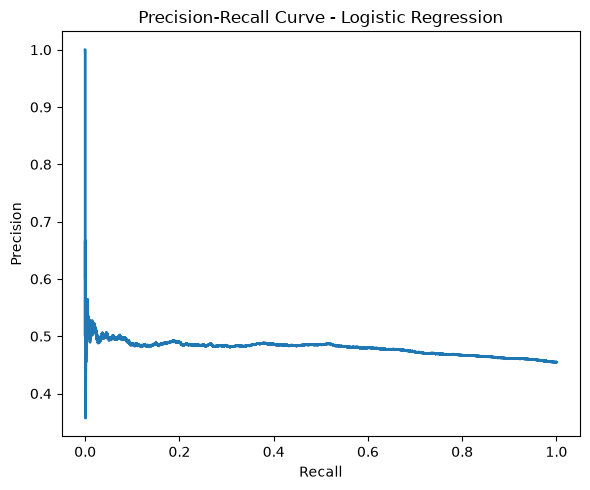

In [38]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Logistic Regression")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH /
    "logistic_regression_pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. Baseline Model Summary

The performance metrics obtained from the Logistic Regression classifier are summarized below.

This summary will later be expanded to include Decision Tree, Random Forest, XGBoost, and other models, enabling a comprehensive comparison of classification performance.

In [39]:
logistic_summary = pd.DataFrame({

    "Model":["Logistic Regression"],

    "Accuracy":[metrics["Accuracy"]],

    "Precision":[metrics["Precision"]],

    "Recall":[metrics["Recall"]],

    "F1 Score":[metrics["F1 Score"]],

    "ROC AUC":[metrics["ROC AUC"]]

})

logistic_summary

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.5452,0.497748,0.024302,0.046341,0.534808


In [40]:
logistic_summary.to_csv(

    METRIC_PATH /
    "baseline_model_summary.csv",

    index=False

)

# 16. Conclusion

The Logistic Regression classifier served as the baseline machine learning model for this study.

Although it achieved moderate overall accuracy, the classifier demonstrated extremely low recall for attack detection, indicating that a linear decision boundary is insufficient for modelling the complex behavioural patterns present in the VeReMi dataset.

These findings motivate the use of more advanced non-linear classifiers, including Decision Trees, Random Forests, and XGBoost, which are expected to capture complex feature interactions more effectively.

The following notebook extends this work by implementing and evaluating tree-based classification algorithms.